# Marketing Mix Modeling & Media Budget Optimization

This project develops an interpretable Marketing Mix Modeling (MMM) pipeline
to estimate the contribution of marketing channels to business outcomes and
optimize media budget allocation.

The project uses the official simulated national-level marketing dataset
published with Google's Meridian open-source MMM project.

Meridian itself is not used for model training. The modeling pipeline is
implemented independently in Python to explore key MMM concepts including:

- Regression-based marketing attribution
- Multicollinearity diagnostics
- Media adstock and carryover effects
- Saturation and diminishing returns
- Seasonality and control variables
- Media channel interactions
- Bayesian regression
- Time-based model validation
- Channel contribution and ROAS
- Constrained media budget optimization

## Project roadmap

1. Load and inspect the raw data  
2. Build the revenue KPI  
3. Identify media and control variables  
4. Perform EDA and data-quality checks  
5. Add trend and seasonality features  
6. Fit a simple baseline OLS model  
7. Diagnose multicollinearity with VIF  
8. Implement adstock (carryover)  
9. Implement saturation (diminishing returns)  
10. Reserve an untouched final holdout and tune transformation parameters inside the development period  
11. Add a media interaction term  
12. Compare OLS, Ridge, Lasso, ElasticNet, and Bayesian Ridge using development-period time-series CV  
13. Refit the selected model on all development data and evaluate once on the final holdout  
14. Estimate channel contribution and ROAS  
15. Plot response curves  
16. Optimize a fixed media budget  
17. Run scenario analysis


## 0. Imports and settings

In [1]:
# Basic numerical and data libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Statistical modeling
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine-learning models and evaluation
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

# Numerical optimization
from scipy.optimize import minimize

# Make notebook tables easier to read
pd.set_option("display.max_columns", None)  #display all col
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
print("Imports completed successfully.")

Imports completed successfully.


## 1. Load the official Google dataset

In [2]:
# Google Meridian publishes this simulated dataset in its official GitHub repository.
# We download the CSV directly so the notebook is reproducible in Colab.
DATA_URL = (
    "https://raw.githubusercontent.com/google/meridian/"
    "refs/heads/main/meridian/data/simulated_data/csv/"
    "national_all_channels.csv"
)

print("Data URL:")
print(DATA_URL)

Data URL:
https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/national_all_channels.csv


In [3]:
# Read the raw CSV. Keep a separate df_raw so we always preserve the original data.
df_raw = pd.read_csv(DATA_URL)

print("Dataset downloaded successfully.")
print("Shape (rows, columns):", df_raw.shape)
print("\nFirst 5 rows:")
display(df_raw.head())

Dataset downloaded successfully.
Shape (rows, columns): (156, 17)

First 5 rows:


,time,conversions,revenue_per_conversion,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Organic_channel0_impression,competitor_sales_control,sentiment_score_control,Promo
0,2021-01-25,"386,300,926.300",0.020,44340630,10537596,6501889,66738506,53026011,"325,137.568","101,595.404","48,315.045","520,082.524","413,173.984",24028870,-0.032,-0.342,0.272
1,2021-02-01,"355,303,931.300",0.020,47391940,30857600,7966320,79000018,27592214,"347,511.968","297,505.264","59,197.121","615,634.540","214,996.093",29188267,0.312,0.807,0.151
2,2021-02-08,"438,308,889.800",0.020,28960185,23144749,4637739,68442555,20057461,"212,357.019","223,143.885","34,462.688","533,361.917","156,285.964",12051369,-1.244,-0.152,0.596
3,2021-02-15,"418,612,413.700",0.020,38126016,10667077,3029637,70601091,37246623,"279,567.523","102,843.759","22,513.003","550,183.038","290,222.395",9595212,-0.019,-0.378,0.341
4,2021-02-22,"355,785,298.000",0.020,46890794,17925961,10486840,81842660,56259530,"343,837.209","172,828.342","77,926.915","637,786.802","438,369.281",9288846,0.344,0.034,0.366


conversions: the number of target business outcomes in each time period

spend: how much money spend on this ad

revenue = conversions * rev_per_conv

impression: how any times ad gets demoed/exposed

competitor_sales_control: competitor change affects us

sentiment_score_control: customer sentiment

Promo: promotion indicator

### 1.1 Inspect columns and data types

In [4]:
print("Column names:")
for i, column in enumerate(df_raw.columns, start=1):
    print(f"{i:02d}. {column}")

print("\nData types:")
print(df_raw.dtypes)

Column names:
01. time
02. conversions
03. revenue_per_conversion
04. Channel0_impression
05. Channel1_impression
06. Channel2_impression
07. Channel3_impression
08. Channel4_impression
09. Channel0_spend
10. Channel1_spend
11. Channel2_spend
12. Channel3_spend
13. Channel4_spend
14. Organic_channel0_impression
15. competitor_sales_control
16. sentiment_score_control
17. Promo

Data types:
time                            object
conversions                    float64
revenue_per_conversion         float64
Channel0_impression              int64
Channel1_impression              int64
Channel2_impression              int64
Channel3_impression              int64
Channel4_impression              int64
Channel0_spend                 float64
Channel1_spend                 float64
Channel2_spend                 float64
Channel3_spend                 float64
Channel4_spend                 float64
Organic_channel0_impression      int64
competitor_sales_control       float64
sentiment_score_contro

In [5]:
# info() helps us inspect non-null counts and data types in one place.
print("Dataset info:")
df_raw.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         156 non-null    object 
 1   conversions                  156 non-null    float64
 2   revenue_per_conversion       156 non-null    float64
 3   Channel0_impression          156 non-null    int64  
 4   Channel1_impression          156 non-null    int64  
 5   Channel2_impression          156 non-null    int64  
 6   Channel3_impression          156 non-null    int64  
 7   Channel4_impression          156 non-null    int64  
 8   Channel0_spend               156 non-null    float64
 9   Channel1_spend               156 non-null    float64
 10  Channel2_spend               156 non-null    float64
 11  Channel3_spend               156 non-null    float64
 12  Channel4_spend               156 non-null    float64
 13  Organi

### 1.2 Check duplicates and missing values

In [6]:
# Duplicate rows can bias descriptive statistics and model fitting.
duplicate_count = df_raw.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)

# Check missing values column by column.
missing_table = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_pct": df_raw.isna().mean() * 100,
})

print("\nMissing-value summary:")
display(missing_table)

Number of duplicated rows: 0

Missing-value summary:


,missing_count,missing_pct
time,0,0.000
conversions,0,0.000
revenue_per_conversion,0,0.000
Channel0_impression,0,0.000
Channel1_impression,0,0.000
Channel2_impression,0,0.000
Channel3_impression,0,0.000
Channel4_impression,0,0.000
Channel0_spend,0,0.000
Channel1_spend,0,0.000


## 2. Prepare the time column and revenue KPI

Check if time is correctly ordered

In [7]:
# Convert the time column from text to pandas datetime.
df_raw["time"] = pd.to_datetime(df_raw["time"])

# MMM is time-dependent, so always sort chronologically.
df_raw = df_raw.sort_values("time").reset_index(drop=True)

print("Date range:", df_raw["time"].min().date(), "to", df_raw["time"].max().date())
print("Are dates sorted?", df_raw["time"].is_monotonic_increasing)
print("Number of unique dates:", df_raw["time"].nunique())

Date range: 2021-01-25 to 2024-01-15
Are dates sorted? True
Number of unique dates: 156


In [8]:
# The dataset supplies conversions and revenue per conversion.
# We derive weekly revenue as our main business KPI.
df_raw["revenue"] = df_raw["conversions"] * df_raw["revenue_per_conversion"]

print("Revenue calculation check:")
display(
    df_raw[["time", "conversions", "revenue_per_conversion", "revenue"]].head()
)

print("\nRevenue summary:")
print(df_raw["revenue"].describe())

Revenue calculation check:


,time,conversions,revenue_per_conversion,revenue
0,2021-01-25,"386,300,926.300",0.020,"7,725,825.559"
1,2021-02-01,"355,303,931.300",0.020,"7,102,385.863"
2,2021-02-08,"438,308,889.800",0.020,"8,763,055.667"
3,2021-02-15,"418,612,413.700",0.020,"8,366,401.431"
4,2021-02-22,"355,785,298.000",0.020,"7,104,577.903"



Revenue summary:
count         156.000
mean    8,453,320.552
std       584,616.088
min     6,800,398.519
25%     8,110,247.341
50%     8,454,107.699
75%     8,814,923.890
max     9,830,601.968
Name: revenue, dtype: float64


In [9]:
# check data freq: it is weekly data
time_gaps = df_raw["time"].diff()

print(time_gaps.value_counts())

time
7 days    155
Name: count, dtype: int64


## 3. Identify media and control variables

In [10]:
# Paid-media spend columns are anonymized as Channel0, Channel1, etc.
# We intentionally keep these names because the source does not tell us
# whether a channel represents TV, search, social media, etc.
spend_cols = [
    c for c in df_raw.columns
    if c.startswith("Channel") and c.endswith("_spend")
]

# Impression columns describe media exposure.
impression_cols = [
    c for c in df_raw.columns
    if c.startswith("Channel") and c.endswith("_impression")
]

# Non-media variables help prevent the model from attributing every sales change to advertising.
control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo",
]

print("Paid-media spend columns:")
print(spend_cols)
print("\nPaid-media impression columns:")
print(impression_cols)
print("\nControl columns:")
print(control_cols)

Paid-media spend columns:
['Channel0_spend', 'Channel1_spend', 'Channel2_spend', 'Channel3_spend', 'Channel4_spend']

Paid-media impression columns:
['Channel0_impression', 'Channel1_impression', 'Channel2_impression', 'Channel3_impression', 'Channel4_impression']

Control columns:
['competitor_sales_control', 'sentiment_score_control', 'Promo']


In [11]:
# Sanity check: confirm every feature we plan to use actually exists in case csv file changes online.
required_cols = ["time", "revenue"] + spend_cols + control_cols # no impression col
missing_required = [c for c in required_cols if c not in df_raw.columns]

print("Required columns missing from dataset:", missing_required)
assert len(missing_required) == 0, "A required column is missing."
print("Column check passed.")

Required columns missing from dataset: []
Column check passed.


## 4. Exploratory Data Analysis (EDA)

### 4.1 Summary statistics

In [12]:
eda_cols = ["revenue"] + spend_cols + control_cols

print("Summary statistics for modeling variables:")
display(df_raw[eda_cols].describe().T)

Summary statistics for modeling variables:


,count,mean,std,min,25%,50%,75%,max
revenue,156.000,"8,453,320.552","584,616.088","6,800,398.519","8,110,247.341","8,454,107.699","8,814,923.890","9,830,601.968"
Channel0_spend,156.000,"259,626.366","89,012.246","57,570.595","198,312.099","256,363.751","329,645.612","468,308.323"
Channel1_spend,156.000,"200,771.142","98,389.305","26,317.853","129,277.705","186,760.450","258,803.118","504,880.566"
Channel2_spend,156.000,"77,431.727","67,667.057",0.000,"24,503.256","60,355.361","116,437.779","342,458.378"
Channel3_spend,156.000,"563,207.425","173,630.629","140,016.653","439,171.584","552,137.473","655,703.719","1,093,058.801"
Channel4_spend,156.000,"305,965.920","124,831.581","54,318.390","213,900.306","294,065.406","388,343.209","652,244.540"
competitor_sales_control,156.000,-0.045,0.707,-1.952,-0.544,-0.076,0.431,2.131
sentiment_score_control,156.000,-0.026,0.620,-1.860,-0.393,-0.060,0.392,1.965
Promo,156.000,0.496,0.306,0.012,0.257,0.452,0.688,1.473


### 4.2 Revenue over time

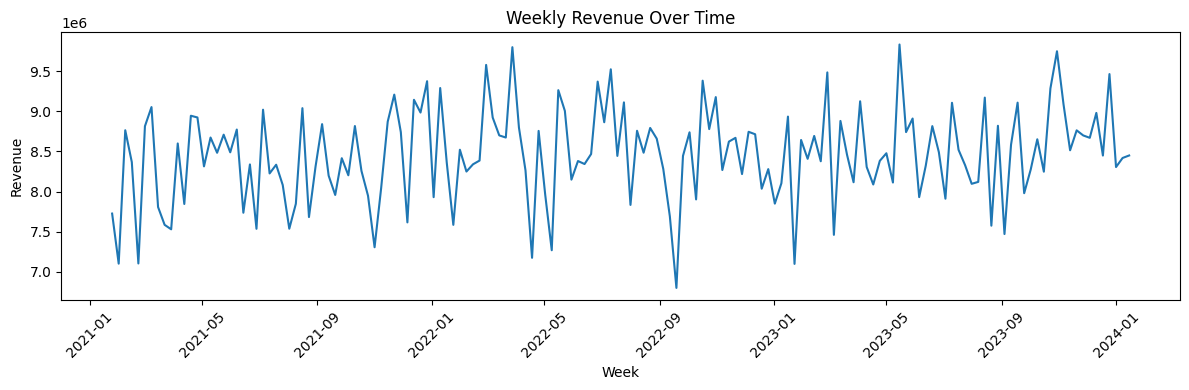

Check the chart for trend, seasonality, spikes, or structural changes.


In [13]:
plt.figure(figsize=(12, 4))
plt.plot(df_raw["time"], df_raw["revenue"])
plt.title("Weekly Revenue Over Time")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Check the chart for trend, seasonality, spikes, or structural changes.")

### 4.3 Media spend over time

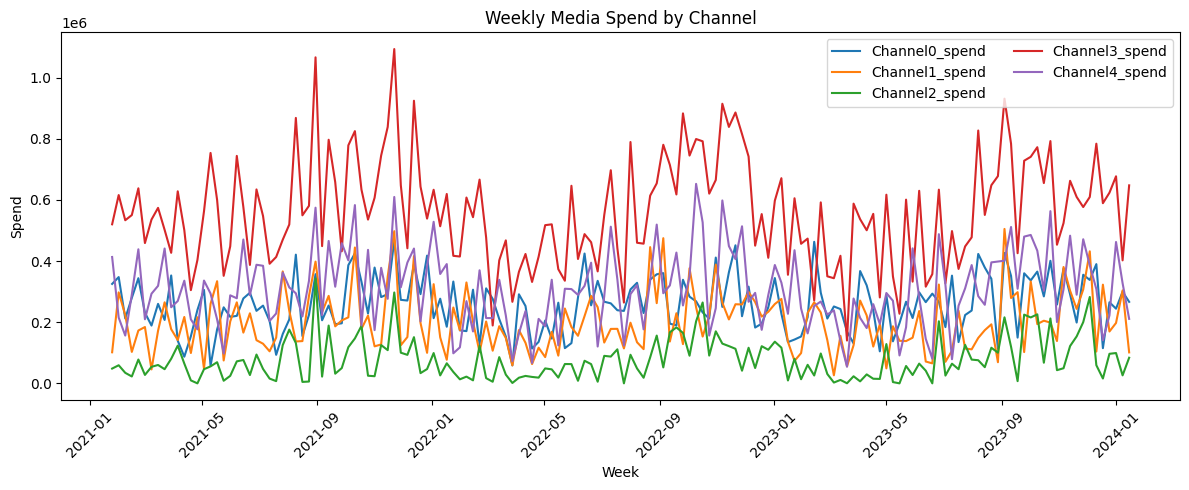

Look for channels that move together; that can create multicollinearity.


In [14]:
plt.figure(figsize=(12, 5))
for col in spend_cols:
    plt.plot(df_raw["time"], df_raw[col], label=col)

plt.title("Weekly Media Spend by Channel")
plt.xlabel("Week")
plt.ylabel("Spend")
plt.legend(ncol=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Look for channels that move together; that can create multicollinearity.")

### 4.4 Correlation analysis

In [15]:
# calc Pearson correlation coefficient
# correlation ([-1,1]): 2 var tends to change simutaniously? how strong is this relationship?

correlation_matrix = df_raw[eda_cols].corr()

print("Correlation with revenue:")
display(
    correlation_matrix["revenue"]
    .sort_values(ascending=False)
    .to_frame("corr_with_revenue")
)

Correlation with revenue:


,corr_with_revenue
revenue,1.000
Promo,0.299
Channel0_spend,0.050
Channel1_spend,0.013
sentiment_score_control,-0.056
Channel2_spend,-0.111
Channel3_spend,-0.124
Channel4_spend,-0.180
competitor_sales_control,-0.381


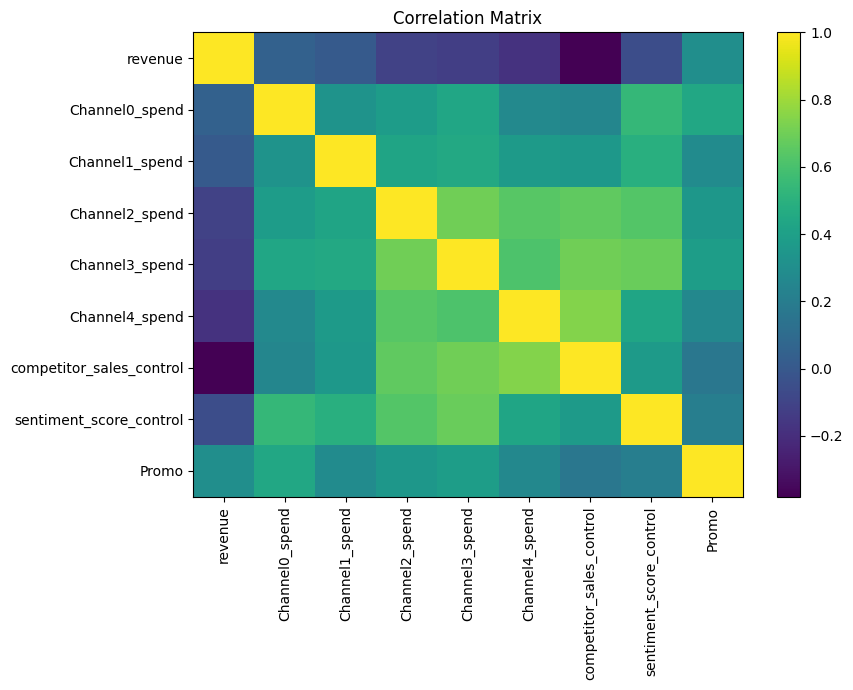

Reminder: correlation is descriptive; it is not causal attribution.


In [16]:
# Plot the full correlation matrix without using seaborn.
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlation_matrix.values, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)
fig.colorbar(image, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Reminder: correlation is descriptive; it is not causal attribution.")

In [17]:
# Check how closely spend and impressions move together within each paid channel.
# This helps explain why the main MMM uses spend as the media input
# instead of including both raw spend and raw impressions.

spend_impression_corr = []

for spend_col in spend_cols:
    channel = spend_col.replace("_spend", "")
    impression_col = f"{channel}_impression"

    if impression_col in df_raw.columns:
        corr = df_raw[spend_col].corr(df_raw[impression_col])

        spend_impression_corr.append({
            "channel": channel,
            "spend_impression_corr": corr,
        })

spend_impression_corr_df = pd.DataFrame(spend_impression_corr)

print("Spend–impression correlation by channel:")
display(spend_impression_corr_df)

Spend–impression correlation by channel:


,channel,spend_impression_corr
0,Channel0,1.000
1,Channel1,1.000
2,Channel2,1.000
3,Channel3,1.000
4,Channel4,1.000


## 5. Add trend and seasonality features

Revenue=MediaEffect+OtherEffects

time is a factor to revenue.

time longer -> company bigger -> revenue higher

trend: general growth over time

season diff

so, Revenuet​=Mediat​+Trendt​+Seasonalityt​+Controlst​+ϵt​

Revenuet​=β0​+c∑​βc​Spendc,t​+βControlst​+βtrend​Trendt​+FourierSeasonalityt​+ϵt​​

In [18]:
def add_time_features(frame):
    """Add a linear trend and Fourier terms for recurring seasonal patterns."""
    out = frame.copy()
    t = np.arange(len(out), dtype=float)

    # Linear long-term trend.
    out["trend"] = t

    # 52-week sine/cosine terms approximate annual seasonality.
    # β1​sin(⋅)+β2​cos(⋅): Asin(ωt+ϕ)
    # A: how strong is seasonality, ϕ: seasonality peak when?
    out["sin_52"] = np.sin(2 * np.pi * t / 52.0)
    out["cos_52"] = np.cos(2 * np.pi * t / 52.0) # allow phase shift to move peak

    # 26-week terms allow a second seasonal pattern within a year.
    out["sin_26"] = np.sin(2 * np.pi * t / 26.0)
    out["cos_26"] = np.cos(2 * np.pi * t / 26.0)

    return out

# Work on a new dataframe from this point onward.
df = add_time_features(df_raw)
time_cols = ["trend", "sin_52", "cos_52", "sin_26", "cos_26"]

print("New time features:", time_cols)
display(df[["time"] + time_cols].head())

New time features: ['trend', 'sin_52', 'cos_52', 'sin_26', 'cos_26']


,time,trend,sin_52,cos_52,sin_26,cos_26
0,2021-01-25,0.000,0.000,1.000,0.000,1.000
1,2021-02-01,1.000,0.121,0.993,0.239,0.971
2,2021-02-08,2.000,0.239,0.971,0.465,0.885
3,2021-02-15,3.000,0.355,0.935,0.663,0.749
4,2021-02-22,4.000,0.465,0.885,0.823,0.568


## 6. Baseline OLS regression

The baseline deliberately uses **raw same-week spend**. It gives us a simple reference model before MMM-specific transformations such as adstock and saturation.

In [19]:
# Baseline explanatory variables.
baseline_features = spend_cols + control_cols + time_cols

print("Baseline features:")
for feature in baseline_features:
    print("-", feature)
print("Total baseline features:", len(baseline_features))

Baseline features:
- Channel0_spend
- Channel1_spend
- Channel2_spend
- Channel3_spend
- Channel4_spend
- competitor_sales_control
- sentiment_score_control
- Promo
- trend
- sin_52
- cos_52
- sin_26
- cos_26
Total baseline features: 13


In [20]:
# statsmodels requires us to add the intercept explicitly.
# Revenue=Media+Controls+Trend+Seasonality+Error
X_base = sm.add_constant(df[baseline_features])
y = df["revenue"]

print("X shape:", X_base.shape)
print("y shape:", y.shape)
print("\nFirst rows of X:")
display(X_base.head())

X shape: (156, 14)
y shape: (156,)

First rows of X:


,const,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,competitor_sales_control,sentiment_score_control,Promo,trend,sin_52,cos_52,sin_26,cos_26
0,1.000,"325,137.568","101,595.404","48,315.045","520,082.524","413,173.984",-0.032,-0.342,0.272,0.000,0.000,1.000,0.000,1.000
1,1.000,"347,511.968","297,505.264","59,197.121","615,634.540","214,996.093",0.312,0.807,0.151,1.000,0.121,0.993,0.239,0.971
2,1.000,"212,357.019","223,143.885","34,462.688","533,361.917","156,285.964",-1.244,-0.152,0.596,2.000,0.239,0.971,0.465,0.885
3,1.000,"279,567.523","102,843.759","22,513.003","550,183.038","290,222.395",-0.019,-0.378,0.341,3.000,0.355,0.935,0.663,0.749
4,1.000,"343,837.209","172,828.342","77,926.915","637,786.802","438,369.281",0.344,0.034,0.366,4.000,0.465,0.885,0.823,0.568


In [21]:
# Fit ordinary least squares regression.
ols_base = sm.OLS(y, X_base).fit()

print("Baseline OLS fitted.")
print("R-squared:", round(ols_base.rsquared, 4)) # The model explains 36.5% of the variation in revenue
print("Adjusted R-squared:", round(ols_base.rsquared_adj, 4)) #penalize features #
print("\nFull statistical summary:")
print(ols_base.summary())

Baseline OLS fitted.
R-squared: 0.3651
Adjusted R-squared: 0.307

Full statistical summary:
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     6.283
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.97e-09
Time:                        01:17:19   Log-Likelihood:                -2256.9
No. Observations:                 156   AIC:                             4542.
Df Residuals:                     142   BIC:                             4584.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

F test: all predictors useless

p(f): small prob to reject F null hypothesis

t: coef/SE(coef) : how close is coefficient to standard errors？ higher the better, meaning not 0 coef

p>|t|: prop of null hypo this predictor not related to y (coef = 0)

confidence interval: if contain 0, no confidence to distinguish negative / zero / positive

## 7. Diagnose multicollinearity with Variance Inflation Factor(VIF)

multicollinearity: predictors related to each other, make prediction unstable

VIF: Beacuse one predictor can be explained by another, its coefficient uncertainty gets inflated to how much

VIF = 1/1-R sqaure

Take Channel0Spend as y, other predictors as x. Check R square for this: asking how much other x can explain Channel0. higher R2 (0.95) means higher VIF (>5) and info overlay. 0 R2: 1 VIF

In [22]:
def calculate_vif(frame):
    """Return Variance Inflation Factor for each feature."""
    X = frame.astype(float).copy()
    rows = []

    for i, column in enumerate(X.columns):
        # for every i, how much can be explained by others (relation of x and other x)
        vif = variance_inflation_factor(X.values, i)
        rows.append({"feature": column, "VIF": vif})

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

# Do not include the intercept in VIF.
vif_results = calculate_vif(df[baseline_features])

print("VIF results:")
display(vif_results)
print("High VIF suggests that a feature can be explained by other predictors.")

VIF results:


,feature,VIF
5,competitor_sales_control,4.237
3,Channel3_spend,4.165
6,sentiment_score_control,3.682
2,Channel2_spend,3.043
4,Channel4_spend,2.600
9,sin_52,2.080
7,Promo,1.882
0,Channel0_spend,1.746
1,Channel1_spend,1.460
8,trend,1.198


High VIF suggests that a feature can be explained by other predictors.


In [23]:
# corr = df[baseline_features].corr()

# display(corr.round(3))


# # if vif for c3 is very high, we need to find which one correlates to this and combine both into 1
# target_feature = "Channel3_spend"


# other_features = [
#     col for col in baseline_features
#     if col != target_feature
# ]

# X_aux = sm.add_constant(df[other_features])
# y_aux = df[target_feature]

# aux_model = sm.OLS(y_aux, X_aux).fit()

# print(aux_model.summary())

## 8. MMM transformation 1: Adstock (carryover)

carryover effect: previous spend also affects future revenue, CurrentSpend+PreviousSpendEffect

In [24]:
def geometric_adstock(values, decay):
    """
    Apply geometric adstock.

    adstock[t] = spend[t] + decay * adstock[t-1]

    decay close to 0 -> short memory
    decay close to 1 -> long carryover
    """
    values = np.asarray(values, dtype=float)
    transformed = np.zeros_like(values, dtype=float)

    transformed[0] = values[0]
    for t in range(1, len(values)):
        transformed[t] = values[t] + decay * transformed[t - 1]

    return transformed

# Tiny hand-check before applying it to the real dataset.
toy_spend = np.array([100.0, 0.0, 0.0, 0.0])
toy_adstock = geometric_adstock(toy_spend, decay=0.5)

print("Toy spend:   ", toy_spend)
print("Toy adstock: ", toy_adstock)
print("Expected approximately: [100, 50, 25, 12.5]")

Toy spend:    [100.   0.   0.   0.]
Toy adstock:  [100.   50.   25.   12.5]
Expected approximately: [100, 50, 25, 12.5]


In [25]:
# Visual example using Channel0 with an illustrative decay value.
example_channel = spend_cols[0]
example_decay = 0.5
example_adstock = geometric_adstock(df[example_channel].values, example_decay)

print("Example channel:", example_channel)
print("Example decay:", example_decay)
print("\nRaw vs adstocked first 10 observations:")
display(pd.DataFrame({
    "raw_spend": df[example_channel].head(10).values,
    "adstocked_spend": example_adstock[:10],
}))

Example channel: Channel0_spend
Example decay: 0.5

Raw vs adstocked first 10 observations:


,raw_spend,adstocked_spend
0,"325,137.568","325,137.568"
1,"347,511.968","510,080.752"
2,"212,357.019","467,397.396"
3,"279,567.523","513,266.221"
4,"343,837.209","600,470.320"
5,"230,954.220","531,189.380"
6,"188,985.826","454,580.516"
7,"259,838.598","487,128.856"
8,"207,319.137","450,883.565"
9,"352,719.492","578,161.275"


## 9. MMM transformation 2: Saturation / diminishing returns

few ads:
evident effect

many ads:
extra effect not that much

Diminishing Returns

close to upper bounds: Saturation

Hill(x)= x.power(s)​​ / (x.power(s)+k.power(s))

In [26]:
def hill_saturation(values, half_saturation, slope=1.0):
    """
    Hill saturation curve.

    half_saturation controls where the curve reaches roughly half its maximum (0.5).
    slope controls the shape/steepness of the response curve.
    """
    x = np.maximum(np.asarray(values, dtype=float), 0.0)
    theta = max(float(half_saturation), 1e-9)

    numerator = np.power(x, slope)
    denominator = numerator + np.power(theta, slope)
    return numerator / np.maximum(denominator, 1e-12)

# Simple numerical check.
toy_values = np.array([0, 25, 50, 100, 200], dtype=float)
toy_saturation = hill_saturation(toy_values, half_saturation=50, slope=1.0)

print("Toy input:", toy_values)
print("Saturated output:", np.round(toy_saturation, 3))
print("Notice how the output approaches 1 instead of increasing forever.")

Toy input: [  0.  25.  50. 100. 200.]
Saturated output: [0.    0.333 0.5   0.667 0.8  ]
Notice how the output approaches 1 instead of increasing forever.


In [27]:
# Combine adstock and saturation for the example channel.
# We choose the median positive adstock value only for this visual demonstration.
positive_values = example_adstock[example_adstock > 0]
example_theta = np.median(positive_values)
example_saturated = hill_saturation(example_adstock, example_theta)

print("Example half-saturation value (theta):", round(example_theta, 3))
print("\nFirst 10 transformed observations:")
display(pd.DataFrame({
    "raw_spend": df[example_channel].head(10).values,
    "adstock": example_adstock[:10],
    "adstock_plus_saturation": example_saturated[:10],
}))

Example half-saturation value (theta): 513110.246

First 10 transformed observations:


,raw_spend,adstock,adstock_plus_saturation
0,"325,137.568","325,137.568",0.388
1,"347,511.968","510,080.752",0.499
2,"212,357.019","467,397.396",0.477
3,"279,567.523","513,266.221",0.500
4,"343,837.209","600,470.320",0.539
5,"230,954.220","531,189.380",0.509
6,"188,985.826","454,580.516",0.470
7,"259,838.598","487,128.856",0.487
8,"207,319.137","450,883.565",0.468
9,"352,719.492","578,161.275",0.530


## 10. Reserve final holdout and tune adstock / saturation parameters


need to find decay、half_saturation、slope(fix to 1 for simplicity) for each channel

we want the hyper-para to predict future data well

Important: the final holdout must stay unknown while we tune these hyperparameters.


We first reserve the **last 20 weeks** as a completely untouched final holdout.  
All transformation tuning happens only inside the earlier **development period**.

Inside development data, we use expanding-window `TimeSeriesSplit`. For every fold, `theta` is estimated only from that fold's training history. This avoids using future validation/test information to define the transformation scale.

The final holdout is not used to choose adstock decay, Hill half-saturation, or the regression algorithm.


In [28]:
# Keep the last 20 weeks completely untouched until final evaluation.
# time series: future data should not be used to choose hyperparameters
FINAL_HOLDOUT_WEEKS = 20

development_end = len(df) - FINAL_HOLDOUT_WEEKS

development_df = df.iloc[:development_end].copy()
final_holdout_df = df.iloc[development_end:].copy()

print("Total rows:", len(df))
print("Development rows:", len(development_df))
print("Final holdout rows:", len(final_holdout_df))
print("Development period:", development_df["time"].min().date(), "to", development_df["time"].max().date())
print("Final holdout period:", final_holdout_df["time"].min().date(), "to", final_holdout_df["time"].max().date())

assert len(development_df) + len(final_holdout_df) == len(df)
assert development_df["time"].max() < final_holdout_df["time"].min()
print("Final holdout is separated chronologically and will stay untouched during model selection.")


Total rows: 156
Development rows: 136
Final holdout rows: 20
Development period: 2021-01-25 to 2023-08-28
Final holdout period: 2023-09-04 to 2024-01-15
Final holdout is separated chronologically and will stay untouched during model selection.


In [29]:
def transform_one_channel(full_series, decay, theta_scale, theta_reference_series=None):
    """Apply adstock, then Hill saturation, to one full media series.

    theta_reference_series lets us estimate the Hill scale from training data only.
    If it is not supplied, the full adstocked series is used as the reference.
    """
    adstocked = geometric_adstock(full_series, decay)

    # During CV, theta must be learned only from the fold's training history.
    if theta_reference_series is None:
        reference_adstocked = adstocked
    else:
        reference_adstocked = geometric_adstock(theta_reference_series, decay)

    positive = reference_adstocked[reference_adstocked > 0]
    base_theta = np.median(positive) if len(positive) else 1.0
    theta = max(base_theta * theta_scale, 1e-9)   #adaptive scale for each channel

    saturated = hill_saturation(adstocked, theta, slope=1.0)
    return saturated, theta

# Candidate values are deliberately small so the notebook runs quickly.
decay_grid = [0.0, 0.3, 0.5, 0.7, 0.9]
theta_scale_grid = [0.25, 0.5, 1.0, 2.0]

print("Decay candidates:", decay_grid)
print("Theta-scale candidates:", theta_scale_grid)


Decay candidates: [0.0, 0.3, 0.5, 0.7, 0.9]
Theta-scale candidates: [0.25, 0.5, 1.0, 2.0]


In [30]:
# Tune each channel separately while keeping controls and time features in the regression.
# All tuning happens ONLY inside development data.
# Each validation fold comes after its training fold in time.
tuning_splitter = TimeSeriesSplit(n_splits=3, test_size=20)

best_params = {}
all_tuning_rows = []

y_development = development_df["revenue"].reset_index(drop=True)

for channel in spend_cols:
    best_rmse = np.inf
    best_setting = None

    print(f"\nTuning {channel} ...")

    for decay in decay_grid:
        for theta_scale in theta_scale_grid:
            fold_rmses = []

            for fold, (train_idx, valid_idx) in enumerate(
                tuning_splitter.split(development_df), start=1
            ):
                # Transform through the end of this validation fold so adstock can
                # legitimately carry past training spend into future validation weeks.
                fold_end = valid_idx[-1] + 1 # adstock first val value needs last train value for calc
                channel_history = development_df[channel].iloc[:fold_end].values
                channel_train = development_df[channel].iloc[train_idx].values

                transformed_history, theta = transform_one_channel(
                    channel_history,
                    decay=decay,
                    theta_scale=theta_scale,
                    theta_reference_series=channel_train,
                )

                temp = development_df[control_cols + time_cols].iloc[:fold_end].copy()
                temp["media_transformed"] = transformed_history

                X_train = sm.add_constant(temp.iloc[train_idx], has_constant="add")
                X_valid = sm.add_constant(temp.iloc[valid_idx], has_constant="add")
                y_train_fold = y_development.iloc[train_idx]
                y_valid_fold = y_development.iloc[valid_idx]

                model = sm.OLS(y_train_fold, X_train).fit()
                pred = model.predict(X_valid)
                rmse = np.sqrt(mean_squared_error(y_valid_fold, pred))
                fold_rmses.append(rmse)

            mean_cv_rmse = np.mean(fold_rmses)

            all_tuning_rows.append({
                "channel": channel,
                "decay": decay,
                "theta_scale": theta_scale,
                "mean_CV_RMSE": mean_cv_rmse,
            })

            if mean_cv_rmse < best_rmse:
                best_rmse = mean_cv_rmse
                best_setting = {
                    "decay": decay,
                    "theta_scale": theta_scale,
                    "mean_CV_RMSE": mean_cv_rmse,
                }

    # After selecting decay and theta_scale from development CV,
    # calculate the final theta using ALL development history only.
    development_adstock = geometric_adstock(
        development_df[channel].values,
        best_setting["decay"],
    )
    positive_development = development_adstock[development_adstock > 0]
    base_theta = np.median(positive_development) if len(positive_development) else 1.0
    best_setting["theta"] = max(
        base_theta * best_setting["theta_scale"],
        1e-9,
    )

    best_params[channel] = best_setting
    print("Best setting:", best_setting)

print("\nFinished tuning all channels using development-period CV only.")



Tuning Channel0_spend ...
Best setting: {'decay': 0.7, 'theta_scale': 0.25, 'mean_CV_RMSE': np.float64(493489.71102742694), 'theta': np.float64(208321.31269263494)}

Tuning Channel1_spend ...
Best setting: {'decay': 0.0, 'theta_scale': 1.0, 'mean_CV_RMSE': np.float64(492865.1434469288), 'theta': np.float64(178218.68604)}

Tuning Channel2_spend ...
Best setting: {'decay': 0.0, 'theta_scale': 0.5, 'mean_CV_RMSE': np.float64(486559.1320969071), 'theta': np.float64(28992.269555)}

Tuning Channel3_spend ...
Best setting: {'decay': 0.0, 'theta_scale': 0.25, 'mean_CV_RMSE': np.float64(496734.887583494), 'theta': np.float64(135245.9214175)}

Tuning Channel4_spend ...
Best setting: {'decay': 0.7, 'theta_scale': 2.0, 'mean_CV_RMSE': np.float64(499992.0879804452), 'theta': np.float64(1878928.0014412191)}

Finished tuning all channels using development-period CV only.


0 decay: Channel0 的 selected transformation has no carryover under the tested grid.

theta_scale: lower, earlier saturation

In [31]:
tuning_results = pd.DataFrame(all_tuning_rows)
best_params_table = pd.DataFrame(best_params).T

print("Best transformation parameters by channel:")
display(best_params_table)

print("\nTop 10 candidate settings overall:")
display(tuning_results.sort_values("mean_CV_RMSE").head(10))

print("\nReminder: the final holdout has still not been used.")


Best transformation parameters by channel:


,decay,theta_scale,mean_CV_RMSE,theta
Channel0_spend,0.700,0.250,"493,489.711","208,321.313"
Channel1_spend,0.000,1.000,"492,865.143","178,218.686"
Channel2_spend,0.000,0.500,"486,559.132","28,992.270"
Channel3_spend,0.000,0.250,"496,734.888","135,245.921"
Channel4_spend,0.700,2.000,"499,992.088","1,878,928.001"



Top 10 candidate settings overall:


,channel,decay,theta_scale,mean_CV_RMSE
41,Channel2_spend,0.000,0.500,"486,559.132"
40,Channel2_spend,0.000,0.250,"487,244.257"
42,Channel2_spend,0.000,1.000,"489,923.520"
22,Channel1_spend,0.000,1.000,"492,865.143"
21,Channel1_spend,0.000,0.500,"493,314.538"
12,Channel0_spend,0.700,0.250,"493,489.711"
23,Channel1_spend,0.000,2.000,"493,553.673"
13,Channel0_spend,0.700,0.500,"493,766.863"
44,Channel2_spend,0.300,0.250,"493,832.809"
14,Channel0_spend,0.700,1.000,"494,175.776"



Reminder: the final holdout has still not been used.


## 11. Build the final transformed MMM dataset

In [32]:
# Start from the prepared dataframe and add one transformed feature per paid-media channel.
# The selected decay/theta_scale came only from development CV.
# theta is fixed from development data, then applied unchanged to the full timeline.
df_mmm = df.copy()
media_cols = []

for channel in spend_cols:
    params = best_params[channel]

    # Transform the full chronological series so holdout adstock can inherit
    # carryover from earlier development weeks. This uses spend history, not holdout revenue.
    adstocked_full = geometric_adstock(df[channel].values, params["decay"])
    transformed = hill_saturation(adstocked_full, params["theta"], slope=1.0)

    new_col = channel.replace("_spend", "_mmm")
    df_mmm[new_col] = transformed
    media_cols.append(new_col)

    print(
        f"Created {new_col}: decay={params['decay']}, "
        f"theta_scale={params['theta_scale']}, theta={params['theta']:.3f}"
    )

print("\nFinal transformed media columns:")
print(media_cols)


Created Channel0_mmm: decay=0.7, theta_scale=0.25, theta=208321.313
Created Channel1_mmm: decay=0.0, theta_scale=1.0, theta=178218.686
Created Channel2_mmm: decay=0.0, theta_scale=0.5, theta=28992.270
Created Channel3_mmm: decay=0.0, theta_scale=0.25, theta=135245.921
Created Channel4_mmm: decay=0.7, theta_scale=2.0, theta=1878928.001

Final transformed media columns:
['Channel0_mmm', 'Channel1_mmm', 'Channel2_mmm', 'Channel3_mmm', 'Channel4_mmm']


In [33]:
# Inspect raw spend and transformed media side by side.
check_cols = ["time"]
for raw_col, mmm_col in zip(spend_cols, media_cols):
    check_cols.extend([raw_col, mmm_col])

print("Raw vs transformed media features:")
display(df_mmm[check_cols].head(8))

Raw vs transformed media features:


,time,Channel0_spend,Channel0_mmm,Channel1_spend,Channel1_mmm,Channel2_spend,Channel2_mmm,Channel3_spend,Channel3_mmm,Channel4_spend,Channel4_mmm
0,2021-01-25,"325,137.568",0.609,"101,595.404",0.363,"48,315.045",0.625,"520,082.524",0.794,"413,173.984",0.180
1,2021-02-01,"347,511.968",0.734,"297,505.264",0.625,"59,197.121",0.671,"615,634.540",0.820,"214,996.093",0.212
2,2021-02-08,"212,357.019",0.747,"223,143.885",0.556,"34,462.688",0.543,"533,361.917",0.798,"156,285.964",0.213
3,2021-02-15,"279,567.523",0.773,"102,843.759",0.366,"22,513.003",0.437,"550,183.038",0.803,"290,222.395",0.256
4,2021-02-22,"343,837.209",0.801,"172,828.342",0.492,"77,926.915",0.729,"637,786.802",0.825,"438,369.281",0.322
5,2021-03-01,"230,954.220",0.797,"184,143.628",0.508,"27,592.895",0.488,"458,701.943",0.772,"209,498.541",0.307
6,2021-03-08,"188,985.826",0.785,"45,647.896",0.204,"54,031.470",0.651,"535,569.550",0.798,"293,094.729",0.318
7,2021-03-15,"259,838.598",0.792,"172,128.262",0.491,"60,077.836",0.675,"573,777.625",0.809,"318,810.394",0.332


## 12. Add one media interaction term

In [34]:
# # Interaction terms represent possible synergy between two channels.
# # To keep the project interpretable, we add only one demonstration interaction.
# interaction_name = f"{media_cols[0]}_x_{media_cols[1]}"
# df_mmm[interaction_name] = df_mmm[media_cols[0]] * df_mmm[media_cols[1]]

# print("Created interaction feature:", interaction_name)
# display(df_mmm[[media_cols[0], media_cols[1], interaction_name]].head())

## 13. Final feature set

In [35]:
# model_features = media_cols + [interaction_name] + control_cols + time_cols
model_features = media_cols + control_cols + time_cols

print("Final model features:")
for i, feature in enumerate(model_features, start=1):
    print(f"{i:02d}. {feature}")

print("\nFeature matrix shape:", df_mmm[model_features].shape)
print("Any missing values?", df_mmm[model_features].isna().any().any())

Final model features:
01. Channel0_mmm
02. Channel1_mmm
03. Channel2_mmm
04. Channel3_mmm
05. Channel4_mmm
06. competitor_sales_control
07. sentiment_score_control
08. Promo
09. trend
10. sin_52
11. cos_52
12. sin_26
13. cos_26

Feature matrix shape: (156, 13)
Any missing values? False


## 14. Development / untouched final holdout split


In [36]:
# Reuse the boundary created BEFORE hyperparameter tuning.
# The last 20 weeks are still untouched by transformation tuning and model selection.
development = df_mmm.iloc[:development_end].copy()
test = df_mmm.iloc[development_end:].copy()

X_development = development[model_features]
X_test = test[model_features]
y_development = development["revenue"]
y_test = test["revenue"]

print("Development shape:", X_development.shape)
print("Final test shape:", X_test.shape)
print("Development ends:", development["time"].max().date())
print("Final test starts:", test["time"].min().date())


Development shape: (136, 13)
Final test shape: (20, 13)
Development ends: 2023-08-28
Final test starts: 2023-09-04


## 15. Compare models using development-period time-series cross-validation


In [37]:
def rolling_cv(model_name, model_factory, X_df, y_series, n_splits=3):
    """Evaluate one model using expanding-window TimeSeriesSplit."""
    splitter = TimeSeriesSplit(n_splits=n_splits, test_size=20)
    rows = []

    for fold, (train_idx, valid_idx) in enumerate(splitter.split(X_df), start=1):
        X_tr = X_df.iloc[train_idx]
        X_va = X_df.iloc[valid_idx]
        y_tr = y_series.iloc[train_idx]
        y_va = y_series.iloc[valid_idx]

        if model_name == "OLS":
            # statsmodels requires us to add the intercept explicitly.
            X_tr_model = sm.add_constant(X_tr, has_constant="add")
            X_va_model = sm.add_constant(X_va, has_constant="add")
            model = sm.OLS(y_tr, X_tr_model).fit()
            pred = model.predict(X_va_model)
        else:
            # Regularized models are scale-sensitive, so fit the scaler on
            # this fold's training data only, then transform validation data.
            fold_scaler = StandardScaler()   #mean 0 std 1
            X_tr_scaled = fold_scaler.fit_transform(X_tr)
            #already know mean and std from train fit_transfrom, no need to do fit to learn that
            X_va_scaled = fold_scaler.transform(X_va)
            model = model_factory()
            model.fit(X_tr_scaled, y_tr)
            pred = model.predict(X_va_scaled)

        rows.append({
            "model": model_name,
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(valid_idx),
            "MAE": mean_absolute_error(y_va, pred),
            "RMSE": np.sqrt(mean_squared_error(y_va, pred)),
            "R2": r2_score(y_va, pred),
        })

    return pd.DataFrame(rows)

print("Rolling CV helper created.")


Rolling CV helper created.


In [38]:
# Compare every candidate algorithm on the SAME development-period folds.
# The final holdout is not used here.
model_factories = {
    "OLS": None,
    "Ridge": lambda: Ridge(alpha=1.0),  # L2 regularization to penalize extreme coef to reduce var
    "Lasso": lambda: Lasso(alpha=0.01, max_iter=20000),  # L1 reg: can make coef 0, which can do feature sel
    "ElasticNet": lambda: ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000), # 50% L1+50% L2
    "BayesianRidge": lambda: BayesianRidge(),  # bayesian shrinkage
}

cv_tables = []

for name, factory in model_factories.items():
    result = rolling_cv(
        model_name=name,
        model_factory=factory,
        X_df=X_development,
        y_series=y_development,
        n_splits=3,
    )
    cv_tables.append(result)

cv_results = pd.concat(cv_tables, ignore_index=True)

print("Fold-by-fold development CV results:")
display(cv_results)


Fold-by-fold development CV results:


,model,fold,train_rows,validation_rows,MAE,RMSE,R2
0,OLS,1,76,20,"374,694.428","491,229.838",0.352
1,OLS,2,96,20,"480,598.192","633,552.009",-0.382
2,OLS,3,116,20,"324,123.410","408,878.773",0.362
3,Ridge,1,76,20,"373,842.584","492,609.186",0.348
4,Ridge,2,96,20,"470,150.054","622,936.534",-0.336
5,Ridge,3,116,20,"323,354.270","406,758.223",0.368
6,Lasso,1,76,20,"374,694.428","491,229.850",0.352
7,Lasso,2,96,20,"480,598.098","633,551.907",-0.382
8,Lasso,3,116,20,"324,123.403","408,878.752",0.362
9,ElasticNet,1,76,20,"374,083.538","491,763.860",0.351


## 16. Select the model from development CV


In [39]:
# Average each model's validation metrics across the expanding-window folds.
model_comparison = (
    cv_results
    .groupby("model")[["MAE", "RMSE", "R2"]]
    .mean()
    .sort_values("RMSE")
    .reset_index()
)

print("Development CV model comparison (lower RMSE is better):")
display(model_comparison)

best_model_name = model_comparison.iloc[0]["model"]
print("Selected model from development CV:", best_model_name)
print("Final holdout has still not been used.")


Development CV model comparison (lower RMSE is better):


,model,MAE,RMSE,R2
0,Ridge,"389,115.636","507,434.647",0.127
1,ElasticNet,"391,057.098","509,202.013",0.119
2,Lasso,"393,138.643","511,220.170",0.111
3,OLS,"393,138.676","511,220.206",0.111
4,BayesianRidge,"432,331.292","560,000.327",-0.022


Selected model from development CV: Ridge
Final holdout has still not been used.


In [40]:
# Show the selected model's fold-by-fold results so we can inspect stability over time.
best_model_cv = cv_results[cv_results["model"] == best_model_name].copy()

print(f"Rolling validation results — {best_model_name}:")
display(best_model_cv)
print("\nAverage CV metrics:")
display(best_model_cv[["MAE", "RMSE", "R2"]].mean().to_frame("mean"))


Rolling validation results — Ridge:


,model,fold,train_rows,validation_rows,MAE,RMSE,R2
3,Ridge,1,76,20,"373,842.584","492,609.186",0.348
4,Ridge,2,96,20,"470,150.054","622,936.534",-0.336
5,Ridge,3,116,20,"323,354.270","406,758.223",0.368



Average CV metrics:


,mean
MAE,"389,115.636"
RMSE,"507,434.647"
R2,0.127


## 17. Refit the selected model and evaluate ONCE on the final holdout


In [41]:
# Model selection is finished. Now fit the selected model on ALL development rows.
# Only after that do we open the untouched final 20-week holdout.
final_scaler = None

if best_model_name == "OLS":
    X_development_final = sm.add_constant(X_development, has_constant="add")
    X_test_final = sm.add_constant(X_test, has_constant="add")

    final_model = sm.OLS(y_development, X_development_final).fit()
    final_pred = final_model.predict(X_test_final)
else:
    final_scaler = StandardScaler()
    X_development_scaled = final_scaler.fit_transform(X_development)
    X_test_scaled = final_scaler.transform(X_test)

    final_model = model_factories[best_model_name]()
    final_model.fit(X_development_scaled, y_development)
    final_pred = final_model.predict(X_test_scaled)

final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print("Selected model:", best_model_name)
print("FINAL holdout metrics:")
print("MAE :", round(final_mae, 3))
print("RMSE:", round(final_rmse, 3))
print("R²  :", round(final_r2, 4))


Selected model: Ridge
FINAL holdout metrics:
MAE : 311747.129
RMSE: 426169.093
R²  : 0.302


In [42]:
coef_check = pd.DataFrame({
    "feature": model_features,
    "coefficient": final_model.coef_
})

coef_check["abs_coefficient"] = coef_check["coefficient"].abs()

print("model coefficients on standardized features:")
display(
    coef_check
    .sort_values("abs_coefficient", ascending=False)
)

print("Intercept:", final_model.intercept_)
print("Prediction std:", np.std(final_pred))
print("Actual test std:", np.std(y_test))

model coefficients on standardized features:


,feature,coefficient,abs_coefficient
5,competitor_sales_control,"-313,494.379","313,494.379"
7,Promo,"181,433.684","181,433.684"
4,Channel4_mmm,"142,483.000","142,483.000"
2,Channel2_mmm,"-118,857.812","118,857.812"
8,trend,"45,473.520","45,473.520"
9,sin_52,"-29,719.544","29,719.544"
12,cos_26,"-28,985.902","28,985.902"
1,Channel1_mmm,"28,761.147","28,761.147"
10,cos_52,"18,576.106","18,576.106"
3,Channel3_mmm,"17,032.704","17,032.704"


Intercept: 8423420.213410959
Prediction std: 308449.87140186754
Actual test std: 510098.5155105153


## 18. Plot final holdout: actual vs predicted revenue


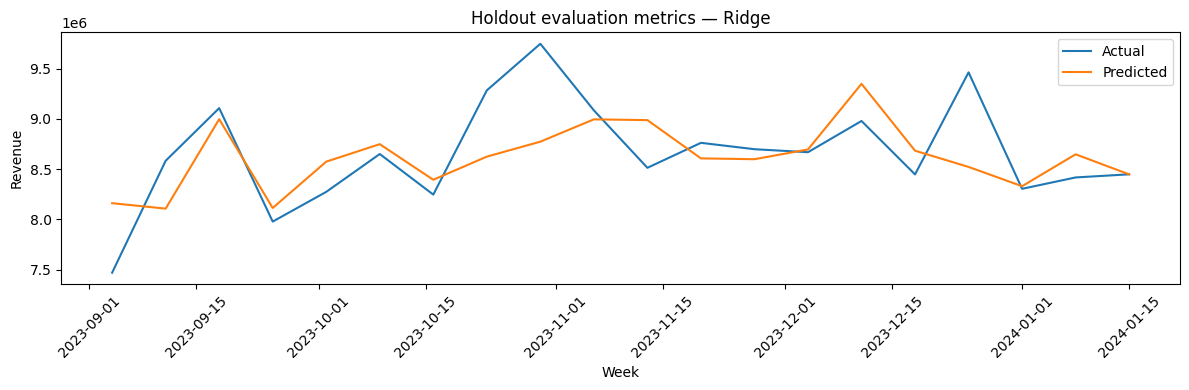

These 20 weeks were excluded from model fitting, media-transformation tuning, and regression-model selection, but were inspected during methodology iteration..


In [43]:
plt.figure(figsize=(12, 4))
plt.plot(test["time"], y_test.values, label="Actual")
plt.plot(test["time"], final_pred, label="Predicted")
plt.title(f"Holdout evaluation metrics — {best_model_name}")
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("These 20 weeks were excluded from model fitting, media-transformation tuning, and regression-model selection, but were inspected during methodology iteration..")


After the untouched holdout evaluation is complete, we may refit the **selected model** on all observations for descriptive business analysis. This does not change or replace the final holdout metrics reported above.

The contribution calculation is **model-implied**, not a claim of experimentally proven causal lift.

# 19. Business Analysis Model

The model-selection and holdout-evaluation stages above answer a predictive question:
**which model specification generalizes best to later weeks?**

After that evaluation is complete, the selected model is refitted on the full 156-week
dataset for **descriptive business analysis**. This refitted model is used consistently
for the remaining sections: media contribution, ROAS, response curves, budget
optimization, and scenario analysis.

This does **not** change the holdout metrics reported above. The full-data refit is not
used to claim new out-of-sample performance; it is a separate descriptive/scenario model.


In [44]:
# After holdout evaluation, refit the selected model on the complete dataset
# for descriptive contribution and scenario analysis.

X_all = df_mmm[model_features].copy()
y_all = df_mmm["revenue"].copy()

business_scaler = None

if best_model_name == "OLS":
    X_all_model = sm.add_constant(X_all, has_constant="add")
    business_model = sm.OLS(y_all, X_all_model).fit()

    business_coef = pd.Series(
        business_model.params[model_features].values,
        index=model_features,
    )
    business_intercept = business_model.params["const"]

    # OLS uses the original feature scale.
    X_business_df = X_all.copy()

else:
    # Fit a new scaler on all 156 weeks because this is now the
    # descriptive business-analysis model, not the holdout-evaluation model.
    business_scaler = StandardScaler()
    X_all_scaled = business_scaler.fit_transform(X_all)  #use all data

    business_model = model_factories[best_model_name]()
    business_model.fit(X_all_scaled, y_all)

    business_coef = pd.Series(
        business_model.coef_,
        index=model_features,
    )
    business_intercept = business_model.intercept_

    X_business_df = pd.DataFrame(
        X_all_scaled,
        columns=model_features,
        index=df_mmm.index,
    )

coef_table = pd.DataFrame({
    "feature": model_features,
    "model_coefficient": business_coef.values,
}).sort_values(
    "model_coefficient",
    ascending=False
)

print(
    "Selected model refitted on all data for descriptive business analysis:",
    best_model_name
)
print("Business-model intercept:", business_intercept)
print("\nBusiness-model coefficients:")
display(coef_table)


Selected model refitted on all data for descriptive business analysis: Ridge
Business-model intercept: 8453320.552099958

Business-model coefficients:


,feature,model_coefficient
7,Promo,"180,701.096"
4,Channel4_mmm,"128,436.757"
8,trend,"52,273.967"
10,cos_52,"22,384.643"
1,Channel1_mmm,"16,905.760"
0,Channel0_mmm,"13,200.429"
3,Channel3_mmm,"5,844.409"
6,sentiment_score_control,"-8,025.775"
11,sin_26,"-24,628.191"
12,cos_26,"-39,279.723"


## Media Contribution

For each paid-media channel, contribution is estimated with a counterfactual prediction.


The counterfactual sets that channel's raw spend to zero for the full history, recomputes
its adstock and Hill transformation with the already-selected transformation parameters,
and leaves all other model features unchanged.

The **same full-data business scaler and business model** are used for observed and
counterfactual predictions. Neither is refitted inside the channel loop.

These values are **model-implied descriptive contributions**, not experimental proof of
causal incremental revenue. Negative values are retained rather than clipped.


In [45]:
# Helper used only for prediction with the already-fitted business model.
def predict_business_model(X_df):
    if best_model_name == "OLS":
        X_model = sm.add_constant(X_df, has_constant="add")
        return np.asarray(business_model.predict(X_model))

    X_scaled = business_scaler.transform(X_df)
    return business_model.predict(X_scaled)


# Observed prediction is common to every channel counterfactual.
X_observed_business = df_mmm[model_features].copy()
pred_observed_business = predict_business_model(X_observed_business)

contribution_results = {}
weekly_contributions = {}

for channel in spend_cols:
    # Example: Channel2_spend -> Channel2_mmm
    channel_name = channel.replace("_spend", "")
    media_feature = f"{channel_name}_mmm"

    # Begin each channel from the same observed world.
    counterfactual_df = df_mmm.copy()

    # Counterfactual assumption:
    # this channel had zero spend throughout the full history.
    counterfactual_df[channel] = 0.0

    # Reuse transformation parameters selected during Development CV.
    decay = best_params[channel]["decay"]
    theta = best_params[channel]["theta"]

    # Zero raw spend -> zero adstock -> zero Hill-transformed media feature.
    counterfactual_adstock = geometric_adstock(
        counterfactual_df[channel].values,
        decay
    )
    counterfactual_mmm = hill_saturation(
        counterfactual_adstock,
        theta
    )
    counterfactual_df[media_feature] = counterfactual_mmm

    # The model must receive the same feature set and fitted preprocessing.
    X_counterfactual = counterfactual_df[model_features].copy()
    pred_counterfactual = predict_business_model(X_counterfactual)

    contribution = (
        pred_observed_business
        - pred_counterfactual
    )

    weekly_contributions[channel] = contribution

    contribution_results[channel] = {
        "average_weekly_contribution": contribution.mean(),
        "total_contribution": contribution.sum(),
        "min_weekly_contribution": contribution.min(),
        "max_weekly_contribution": contribution.max(),
    }


contribution_summary = pd.DataFrame(
    contribution_results
).T

print("Model-implied media contribution:")
display(contribution_summary)


Model-implied media contribution:


,average_weekly_contribution,total_contribution,min_weekly_contribution,max_weekly_contribution
Channel0_spend,"312,176.149","48,699,479.291","238,247.690","332,060.965"
Channel1_spend,"68,129.505","10,628,202.718","17,557.927","100,855.254"
Channel2_spend,"-255,390.137","-39,840,861.406","-389,517.691",0.000
Channel3_spend,"80,539.474","12,564,157.867","51,655.019","90,368.568"
Channel4_spend,"799,943.496","124,791,185.348","419,219.503","1,043,573.970"


### Contribution interpretation

A large total contribution does not automatically mean that a channel is efficient:
a channel may have a large contribution simply because it received a large budget.
The next step therefore compares model-implied contribution with actual media spend.

Because the final model is observational and predictive, a negative contribution should
be read as a **negative conditional model-implied association under the current
specification**, not as proof that the channel caused revenue to fall.


## ROAS: Return on Ad Spend

For each channel:

ROAS = total model implied contribution / total spend

For example, a model-implied ROAS of 2.0 means the current model attributes about
\$2 of revenue contribution to every \$1 of observed spend over the analyzed period.

ROAS here inherits the assumptions and limitations of the contribution calculation.
It is a model-implied descriptive metric, not an experimental causal estimate.


In [46]:
roas_rows = []

for channel in spend_cols:
    total_spend = df_mmm[channel].sum()
    total_contribution = weekly_contributions[channel].sum()

    roas = (
        total_contribution / total_spend
        if total_spend > 0
        else np.nan
    )

    roas_rows.append({
        "channel": channel,
        "total_spend": total_spend,
        "total_model_implied_contribution": total_contribution,
        "model_implied_roas": roas,
    })

roas_table = pd.DataFrame(roas_rows)

print("Channel-level model-implied ROAS:")
display(roas_table)


Channel-level model-implied ROAS:


,channel,total_spend,total_model_implied_contribution,model_implied_roas
0,Channel0_spend,"40,501,713.080","48,699,479.291",1.202
1,Channel1_spend,"31,320,298.202","10,628,202.718",0.339
2,Channel2_spend,"12,079,349.342","-39,840,861.406",-3.298
3,Channel3_spend,"87,860,358.249","12,564,157.867",0.143
4,Channel4_spend,"47,730,683.478","124,791,185.348",2.614


## Response Curves

Contribution and ROAS describe the observed historical allocation. A response curve asks
a different question:

> According to the fitted model, how does predicted revenue change as one channel's spend
> is varied while the rest of the scenario is held fixed?

The scenario below scales one channel's historical spend path from 0% to 200%. For every
spend multiplier, adstock and Hill saturation are recomputed using that channel's fixed
transformation parameters. The full-data business model and scaler remain fixed.

Because the Hill transformation is nonlinear, the resulting curve can show diminishing
returns. These curves are scenario outputs from the fitted model rather than guaranteed
causal responses.


In [47]:
# Spend multipliers used to trace each channel's model-implied response.
spend_multipliers = np.linspace(0.0, 2.0, 41) #【0， 0.05， 0.1， 0.15， ... 2]

response_rows = []

for channel in spend_cols:
    channel_name = channel.replace("_spend", "")
    media_feature = f"{channel_name}_mmm"

    decay = best_params[channel]["decay"]
    theta = best_params[channel]["theta"]

    observed_total_spend = df_mmm[channel].sum()

    for multiplier in spend_multipliers:
        scenario_df = df_mmm.copy()

        # Scale the complete historical spend path for this channel.
        scenario_df[channel] = (
            df_mmm[channel].values * multiplier
        )

        scenario_adstock = geometric_adstock(
            scenario_df[channel].values,
            decay
        )
        scenario_mmm = hill_saturation(
            scenario_adstock,
            theta
        )
        scenario_df[media_feature] = scenario_mmm

        X_scenario = scenario_df[model_features].copy()
        pred_scenario = predict_business_model(X_scenario)

        response_rows.append({
            "channel": channel,
            "spend_multiplier": multiplier,
            "scenario_total_spend": observed_total_spend * multiplier,
            "total_predicted_revenue": pred_scenario.sum(),
            "average_weekly_predicted_revenue": pred_scenario.mean(),
        })


response_curve_df = pd.DataFrame(response_rows)

print("Response-curve scenario table:")
display(response_curve_df.head(10))


Response-curve scenario table:


,channel,spend_multiplier,scenario_total_spend,total_predicted_revenue,average_weekly_predicted_revenue
0,Channel0_spend,0.000,0.000,"1,270,018,526.837","8,141,144.403"
1,Channel0_spend,0.050,"2,025,085.654","1,280,319,329.655","8,207,175.190"
2,Channel0_spend,0.100,"4,050,171.308","1,287,588,692.349","8,253,773.669"
3,Channel0_spend,0.150,"6,075,256.962","1,293,007,497.948","8,288,509.602"
4,Channel0_spend,0.200,"8,100,342.616","1,297,209,041.743","8,315,442.575"
5,Channel0_spend,0.250,"10,125,428.270","1,300,565,287.980","8,336,956.974"
6,Channel0_spend,0.300,"12,150,513.924","1,303,309,758.849","8,354,549.736"
7,Channel0_spend,0.350,"14,175,599.578","1,305,596,758.910","8,369,209.993"
8,Channel0_spend,0.400,"16,200,685.232","1,307,532,480.499","8,381,618.465"
9,Channel0_spend,0.450,"18,225,770.886","1,309,192,470.328","8,392,259.425"


we can see hill saturation:

0% → 5%:
+ $10.30M

5% → 10%:
+ $7.27M

10% → 15%:
+ $5.42M

15% → 20%:
+ $4.20M

20% → 25%:
+ $3.36M

25% → 30%:
+ $2.74M

30% → 35%:
+ $2.29M

35% → 40%:
+ $1.94M

40% → 45%:
+ $1.66M

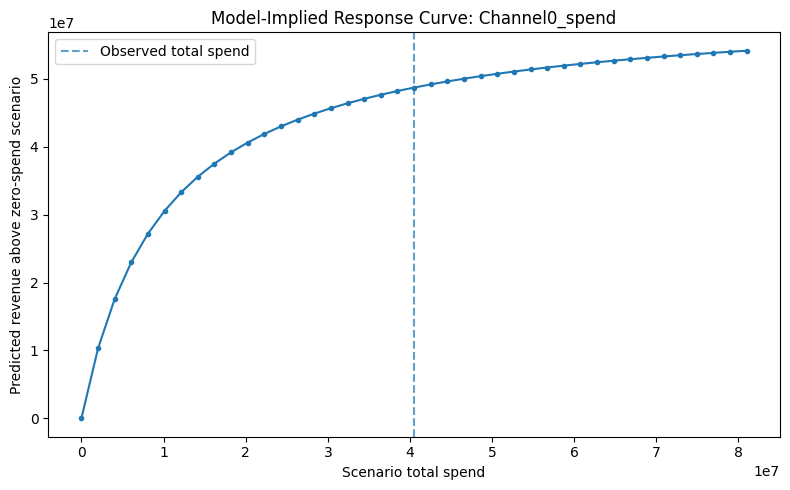

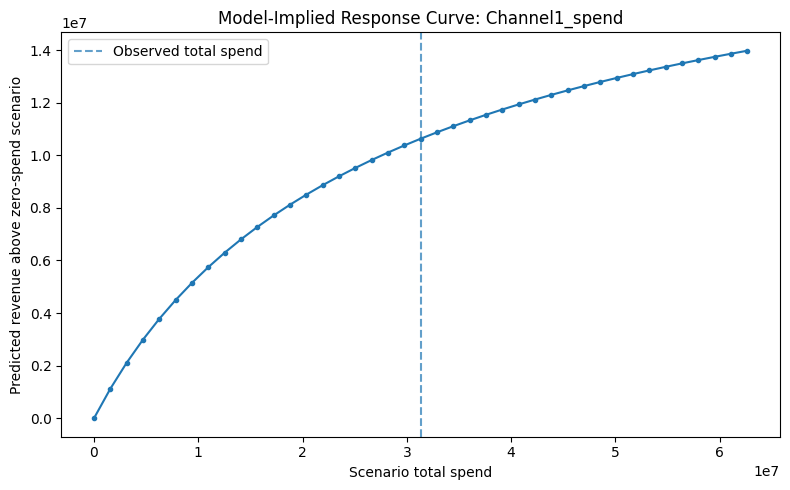

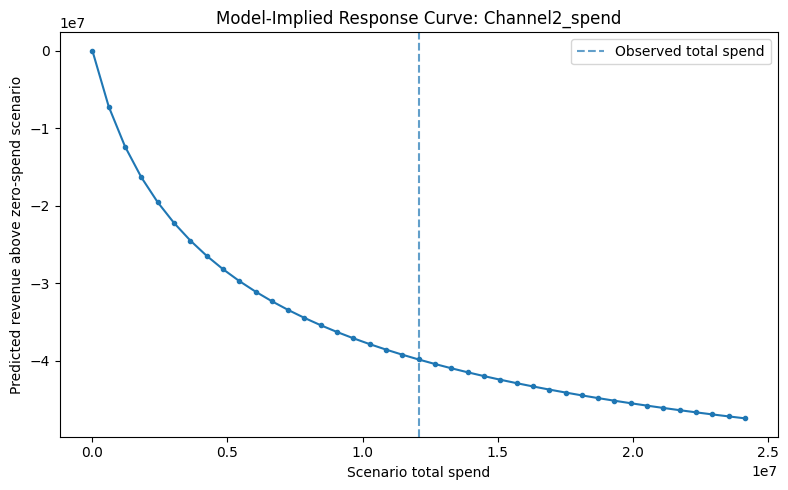

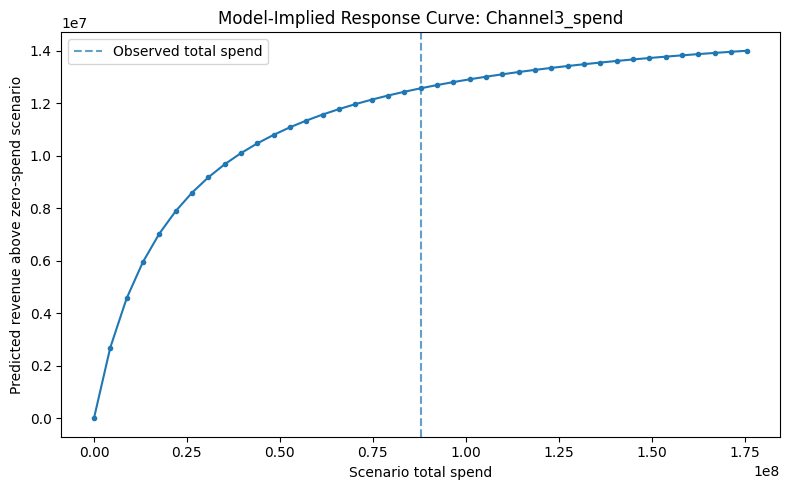

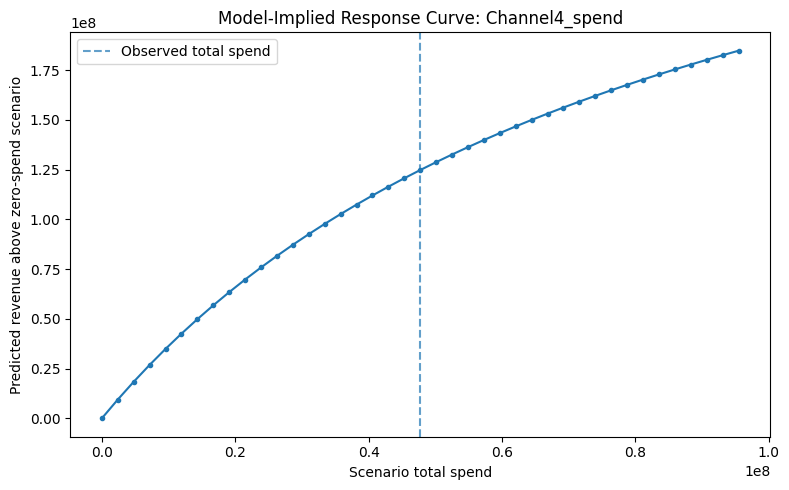

In [48]:
# Plot one response curve per channel.
# Revenue is shown relative to that channel's zero-spend scenario so the
# vertical axis focuses on the model-implied media response.

for channel in spend_cols:
    channel_curve = response_curve_df[
        response_curve_df["channel"] == channel
    ].copy()

    zero_revenue = channel_curve.loc[
        channel_curve["spend_multiplier"] == 0.0,
        "total_predicted_revenue"
    ].iloc[0]

    incremental_revenue = (
        channel_curve["total_predicted_revenue"]
        - zero_revenue
    )

    plt.figure(figsize=(8, 5))
    plt.plot(
        channel_curve["scenario_total_spend"],
        incremental_revenue,
        marker="o",
        markersize=3,
    )

    observed_spend = df_mmm[channel].sum()
    plt.axvline(
        observed_spend,
        linestyle="--",
        alpha=0.7,
        label="Observed total spend"
    )

    plt.title(f"Model-Implied Response Curve: {channel}")
    plt.xlabel("Scenario total spend")
    plt.ylabel("Predicted revenue above zero-spend scenario")
    plt.legend()
    plt.tight_layout()
    plt.show()


## Budget Optimization

The response curves can be used for a simple constrained allocation exercise.

To keep this learning project interpretable, optimization is performed over channel-level
spend multipliers. The total paid-media budget is held approximately equal to the observed
total budget. The objective is the fitted business model's total predicted revenue.

This is a **model-based scenario exercise**, not a recommendation that should be deployed
without additional causal validation, uncertainty analysis, and operational constraints.


In [53]:
from scipy.optimize import minimize

observed_channel_spend = np.array([
    df_mmm[channel].sum()
    for channel in spend_cols
])

observed_total_media_budget = observed_channel_spend.sum()

# Keep the search reasonably close to the range used in the response curves.
# 0.0 = no spend in a channel; 2.0 = twice its observed historical spend.
multiplier_bounds = [
    (0.0, 2.0)
    for _ in spend_cols
]


def predict_total_revenue_for_multipliers(multipliers):
    scenario_df = df_mmm.copy()

    for channel, multiplier in zip(
        spend_cols,
        multipliers
    ):
        channel_name = channel.replace("_spend", "")
        media_feature = f"{channel_name}_mmm"

        decay = best_params[channel]["decay"]
        theta = best_params[channel]["theta"]

        scenario_df[channel] = (
            df_mmm[channel].values * multiplier
        )

        scenario_adstock = geometric_adstock(
            scenario_df[channel].values,
            decay
        )
        scenario_mmm = hill_saturation(
            scenario_adstock,
            theta
        )
        scenario_df[media_feature] = scenario_mmm

    X_scenario = scenario_df[model_features].copy()
    pred_scenario = predict_business_model(X_scenario)

    return pred_scenario.sum()


# Scale the objective to millions of dollars for better numerical stability.
def optimization_objective(multipliers):
    total_revenue = predict_total_revenue_for_multipliers(multipliers)
    return -total_revenue / 1_000_000


def budget_constraint(multipliers):
    scenario_budget = np.sum(
        observed_channel_spend * multipliers
    )

    # Scale to millions of dollars for numerical stability.
    return (
        observed_total_media_budget - scenario_budget
    ) / 1_000_000

print(
    "Original total budget:",
    observed_total_media_budget
)

print(
    "Budget constraint at initial allocation:",
    budget_constraint(
        np.ones(len(spend_cols))
    )
)
optimization_result = minimize(
    optimization_objective,
    x0=np.ones(len(spend_cols)),
    method="SLSQP",
    bounds=multiplier_bounds,
    constraints={
        "type": "eq",
        "fun": budget_constraint,
    },
    options={
        "maxiter": 1000,
        "ftol": 1e-9,
    },
)

print("Optimization succeeded:", optimization_result.success)
print("Optimizer message:", optimization_result.message)


Original total budget: 219492402.35048595
Budget constraint at initial allocation: 0.0
Optimization succeeded: True
Optimizer message: Optimization terminated successfully


In [54]:
optimized_multipliers = optimization_result.x

observed_predicted_revenue = (
    pred_observed_business.sum()
)

optimized_predicted_revenue = (
    predict_total_revenue_for_multipliers(
        optimized_multipliers
    )
)

budget_rows = []

for channel, observed_spend, multiplier in zip(
    spend_cols,
    observed_channel_spend,
    optimized_multipliers
):
    optimized_spend = observed_spend * multiplier

    budget_rows.append({
        "channel": channel,
        "observed_spend": observed_spend,
        "optimized_multiplier": multiplier,
        "optimized_spend": optimized_spend,
        "spend_change": optimized_spend - observed_spend,
    })

budget_allocation_table = pd.DataFrame(
    budget_rows
)

print("Observed total media budget:")
print(observed_total_media_budget)

print("\nOptimized total media budget:")
print(
    budget_allocation_table[
        "optimized_spend"
    ].sum()
)

print("\nObserved model-predicted total revenue:")
print(observed_predicted_revenue)

print("\nOptimized-scenario model-predicted total revenue:")
print(optimized_predicted_revenue)

print("\nModel-implied revenue change:")
print(
    optimized_predicted_revenue
    - observed_predicted_revenue
)

print("\nBudget allocation:")
display(budget_allocation_table)


Observed total media budget:
219492402.35048595

Optimized total media budget:
219492402.3510333

Observed model-predicted total revenue:
1318718006.1275935

Optimized-scenario model-predicted total revenue:
1418899081.7521539

Model-implied revenue change:
100181075.62456036

Budget allocation:


,channel,observed_spend,optimized_multiplier,optimized_spend,spend_change
0,Channel0_spend,"40,501,713.080",1.435,"58,113,878.535","17,612,165.455"
1,Channel1_spend,"31,320,298.202",1.192,"37,323,626.541","6,003,328.339"
2,Channel2_spend,"12,079,349.342",0.000,0.000,"-12,079,349.342"
3,Channel3_spend,"87,860,358.249",0.325,"28,593,530.319","-59,266,827.930"
4,Channel4_spend,"47,730,683.478",2.000,"95,461,366.955","47,730,683.478"


## Scenario Analysis

The optimizer gives one mathematically preferred allocation under the current fitted
model and constraints. Scenario analysis makes the result easier to interpret by comparing
the observed allocation with a few explicit alternatives.

The examples below include the observed allocation, the optimizer result, and equal-budget
allocation across channels. They are descriptive stress tests of the fitted model.


In [55]:
scenario_definitions = {
    "Observed allocation": np.ones(
        len(spend_cols)
    ),
    "Optimized allocation": optimized_multipliers,
}

# Equal dollar budget per channel while preserving the same total budget.
equal_channel_budget = (
    observed_total_media_budget
    / len(spend_cols)
)

equal_budget_multipliers = (
    equal_channel_budget
    / observed_channel_spend
)

scenario_definitions[
    "Equal budget per channel"
] = equal_budget_multipliers


scenario_rows = []

for scenario_name, multipliers in scenario_definitions.items():
    scenario_budget = np.sum(
        observed_channel_spend
        * multipliers
    )

    scenario_revenue = (
        predict_total_revenue_for_multipliers(
            multipliers
        )
    )

    scenario_rows.append({
        "scenario": scenario_name,
        "total_media_budget": scenario_budget,
        "model_predicted_total_revenue": scenario_revenue,
        "predicted_revenue_change_vs_observed": (
            scenario_revenue
            - observed_predicted_revenue
        ),
    })


scenario_summary = pd.DataFrame(
    scenario_rows
)

display(scenario_summary)


,scenario,total_media_budget,model_predicted_total_revenue,predicted_revenue_change_vs_observed
0,Observed allocation,"219,492,402.350","1,318,718,006.128",0.000
1,Optimized allocation,"219,492,402.351","1,418,899,081.752","100,181,075.625"
2,Equal budget per channel,"219,492,402.350","1,299,606,626.753","-19,111,379.375"


## Business-analysis interpretation notes

The outputs in this section should be described carefully:

- **Contribution** is the fitted model's prediction difference between observed media and
  a zero-spend counterfactual.
- **ROAS** divides that model-implied contribution by observed spend.
- **Response curves** vary one channel's spend while holding the fitted model and the
  remaining scenario structure fixed.
- **Budget optimization** searches for an allocation that maximizes the fitted model's
  predicted revenue under a fixed-budget constraint.
- **Scenario analysis** compares alternative allocations under the same fitted model.

These are useful for learning how MMM connects statistical modeling to marketing decisions,
but the simulated observational dataset and simplified model do not justify treating the
outputs as experimentally identified causal effects.
